In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# CSVファイルを読み込む
df = pd.read_csv("eira_record.csv")

# date列を日付データとして扱う
df["date"] = pd.to_datetime(df["date"])

# 最初の5行を表示
df.head()

,date,cycle_phase,mood,anxiety,irritability,sadness,motivation,mental_stability,sleep_hours,sleep_quality,...,humidity_discomfort,work_type,work_stress,interpersonal_stress,unexpected_event,financial_stress,main_stressor,future_category,main_relief,notes
0,2026-05-09,Follicular phase,7.0,2.0,3.0,1.0,7.0,7.0,6.5,4.0,...,3.0,low_activity_night_shift,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
1,2026-05-10,Follicular phase,5.0,5.0,5.0,5.0,3.0,3.0,5.0,3.0,...,2.0,low_activity_night_shift,0.0,0.0,0.0,1.0,"waist pain, future pressure",career,time,I felt pressure and anxiety about the future.
2,2026-05-11,Follicular phase,4.0,3.0,2.0,5.0,2.0,3.0,7.0,5.0,...,1.0,desk,0.0,0.0,0.0,0.0,future pressure,media/publication,time,I was very sleepy so I took a nap for about tw...
3,2026-05-12,Follicular phase,3.0,7.0,5.0,7.0,3.0,3.0,5.0,5.0,...,1.0,low_activity_night_shift,0.0,0.0,0.0,1.0,I felt worried about the travel expenses.,money,40 minutes of sleep during night shift,"I was worried about the travel expenses, so I ..."
4,2026-05-13,Follicular phase,7.0,1.0,1.0,1.0,5.0,7.0,9.0,7.0,...,1.0,desk,0.0,0.0,0.0,0.0,I remembered him.,relationship,Casual conversation with Rem,I realized that I don't study on days when I h...


In [9]:
print(df.columns.tolist())

['date', 'cycle_phase', 'mood', 'anxiety', 'irritability', 'sadness', 'motivation', 'mental_stability', 'sleep_hours', 'sleep_quality', 'work_hours', 'study_hours', 'social_interaction', 'exercise_done', 'exercise_minutes', 'went_outside', 'meals_regular', 'fatigue', 'body_pain', 'headache', 'appetite', 'physical_stability', 'weather', 'temp_discomfort', 'humidity_discomfort', 'work_type', 'work_stress', 'interpersonal_stress', 'unexpected_event', 'financial_stress', 'main_stressor', 'future_category', 'main_relief', 'notes']


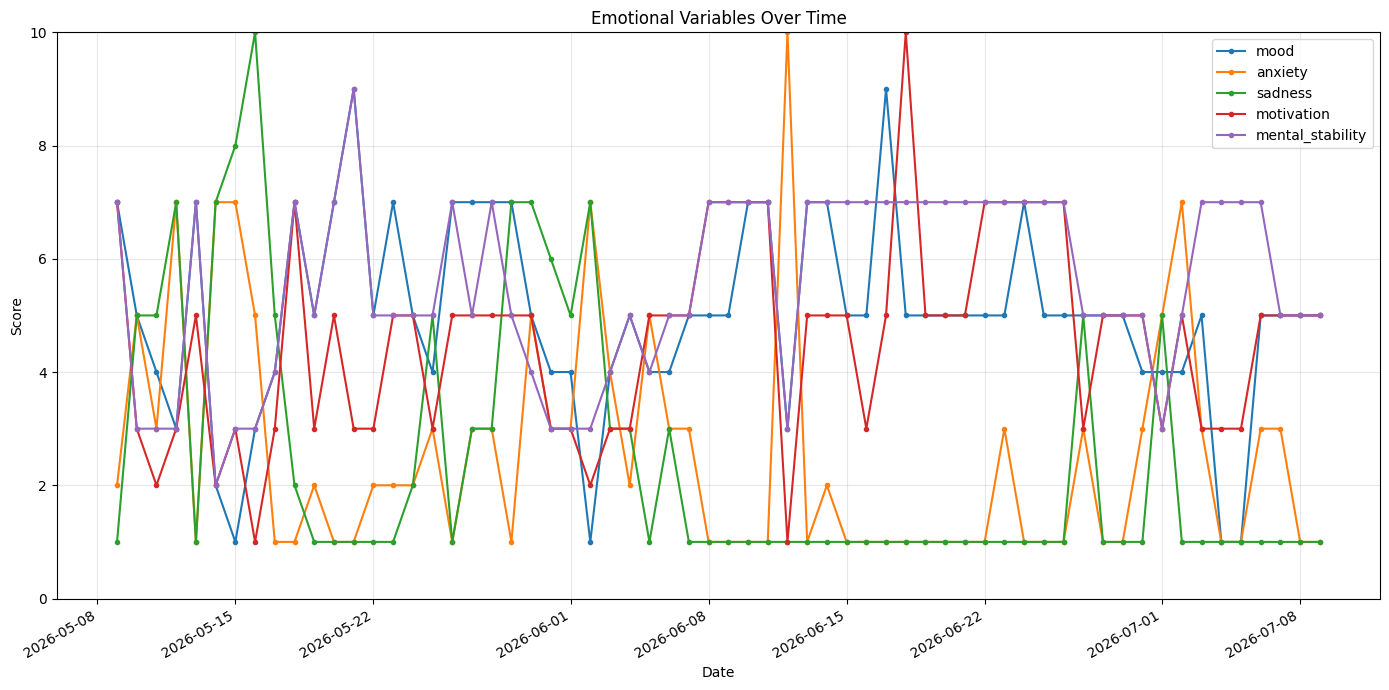

In [4]:
emotion_columns = [
    "mood",
    "anxiety",
    "sadness",
    "motivation",
    "mental_stability",
]

fig, ax = plt.subplots(figsize=(14, 7))

for column in emotion_columns:
    ax.plot(
        df["date"],
        df[column],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=column,
    )

ax.set_title("Emotional Variables Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Score")
ax.set_ylim(0, 10)
ax.legend()
ax.grid(alpha=0.3)

fig.autofmt_xdate()
fig.tight_layout()

fig.savefig(
    "emotional_timeline.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [8]:
import matplotlib.pyplot as plt

# 見たい列だけ選ぶ
columns = [
    "mood",
    "anxiety",
    "sadness",
    "motivation",
    "mental_stability",
    "sleep_hours",
    "fatigue",
    "body_pain",
    "headache",
    "work_hours",
]

# 選んだ列だけ取り出す
numeric_df = df[columns]

# 相関係数を計算
corr = numeric_df.corr()

# 表示
print(corr)

                      mood   anxiety   sadness  motivation  mental_stability  \
mood              1.000000 -0.542771 -0.430696    0.493216          0.576657   
anxiety          -0.542771  1.000000  0.549379   -0.536858         -0.728977   
sadness          -0.430696  0.549379  1.000000   -0.539358         -0.727918   
motivation        0.493216 -0.536858 -0.539358    1.000000          0.619110   
mental_stability  0.576657 -0.728977 -0.727918    0.619110          1.000000   
sleep_hours       0.287131 -0.223347 -0.194473    0.011899          0.236095   
fatigue          -0.318693  0.352189  0.439295   -0.422592         -0.412716   
body_pain        -0.129828  0.139536 -0.011890   -0.107686         -0.230923   
headache         -0.113046  0.191057  0.025336   -0.055156         -0.081991   
work_hours       -0.188170  0.035972 -0.045417    0.029378         -0.011996   

                  sleep_hours   fatigue  body_pain  headache  work_hours  
mood                 0.287131 -0.318693  -0.

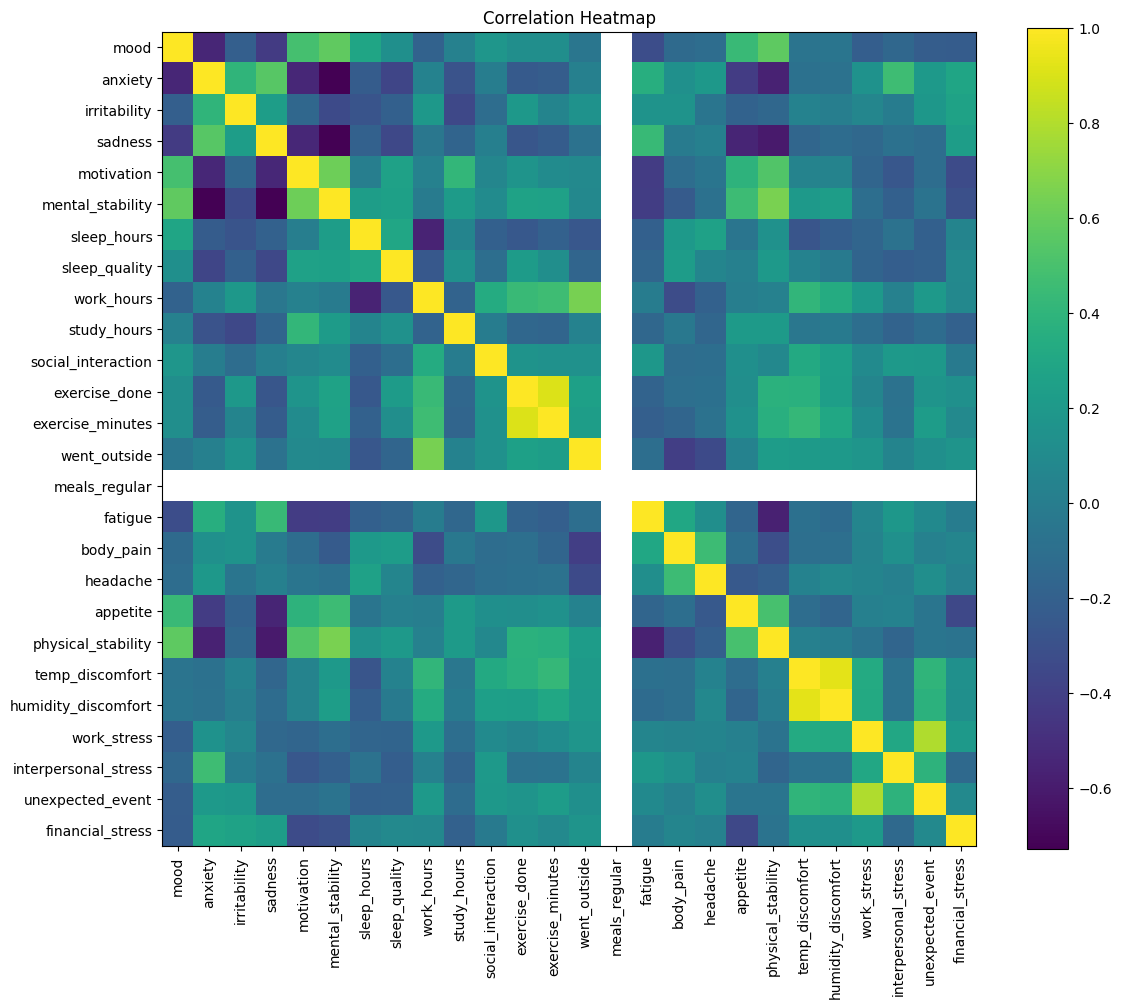

In [6]:
fig, ax = plt.subplots(figsize=(12,10))

image = ax.imshow(corr)

plt.colorbar(image)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)

ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

In [10]:
# 相関分析に使う列
columns = [
    "mood",
    "anxiety",
    "irritability",
    "sadness",
    "motivation",
    "mental_stability",
    "sleep_hours",
    "sleep_quality",
    "work_hours",
    "study_hours",
    "social_interaction",
    "exercise_minutes",
    "fatigue",
    "body_pain",
    "headache",
    "appetite",
    "physical_stability",
    "temp_discomfort",
    "humidity_discomfort",
    "work_stress",
    "interpersonal_stress",
    "unexpected_event",
    "financial_stress",
]

# 選んだ列だけ取り出す
correlation_data = df[columns]

# 相関係数を計算
corr = correlation_data.corr()

# 数値の表を表示
corr.round(2)

,mood,anxiety,irritability,sadness,motivation,mental_stability,sleep_hours,sleep_quality,work_hours,study_hours,...,body_pain,headache,appetite,physical_stability,temp_discomfort,humidity_discomfort,work_stress,interpersonal_stress,unexpected_event,financial_stress
mood,1.00,-0.54,-0.21,-0.43,0.49,0.58,0.29,0.13,-0.19,0.03,...,-0.13,-0.11,0.44,0.57,-0.07,-0.06,-0.21,-0.15,-0.22,-0.23
anxiety,-0.54,1.00,0.40,0.55,-0.54,-0.73,-0.22,-0.37,0.04,-0.29,...,0.14,0.19,-0.42,-0.57,-0.08,-0.07,0.15,0.46,0.20,0.29
irritability,-0.21,0.40,1.00,0.24,-0.15,-0.34,-0.28,-0.20,0.19,-0.35,...,0.16,-0.06,-0.18,-0.15,0.04,0.01,0.07,-0.00,0.18,0.27
sadness,-0.43,0.55,0.24,1.00,-0.54,-0.73,-0.19,-0.35,-0.05,-0.17,...,-0.01,0.03,-0.55,-0.61,-0.16,-0.12,-0.14,-0.08,-0.11,0.23
motivation,0.49,-0.54,-0.15,-0.54,1.00,0.62,0.01,0.26,0.03,0.42,...,-0.11,-0.06,0.39,0.53,0.04,0.05,-0.16,-0.26,-0.11,-0.34
mental_stability,0.58,-0.73,-0.34,-0.73,0.62,1.00,0.24,0.26,-0.01,0.22,...,-0.23,-0.08,0.45,0.65,0.20,0.23,-0.11,-0.20,-0.07,-0.31
sleep_hours,0.29,-0.22,-0.28,-0.19,0.01,0.24,1.00,0.30,-0.56,0.05,...,0.20,0.26,-0.06,0.15,-0.28,-0.21,-0.16,-0.08,-0.20,0.05
sleep_quality,0.13,-0.37,-0.20,-0.35,0.26,0.26,0.30,1.00,-0.26,0.15,...,0.22,0.06,0.03,0.20,0.04,-0.02,-0.17,-0.21,-0.19,0.09
work_hours,-0.19,0.04,0.19,-0.05,0.03,-0.01,-0.56,-0.26,1.00,-0.18,...,-0.33,-0.19,0.01,0.03,0.41,0.34,0.20,0.03,0.20,0.08
study_hours,0.03,-0.29,-0.35,-0.17,0.42,0.22,0.05,0.15,-0.18,1.00,...,-0.04,-0.16,0.22,0.21,-0.04,-0.02,-0.10,-0.18,-0.12,-0.19


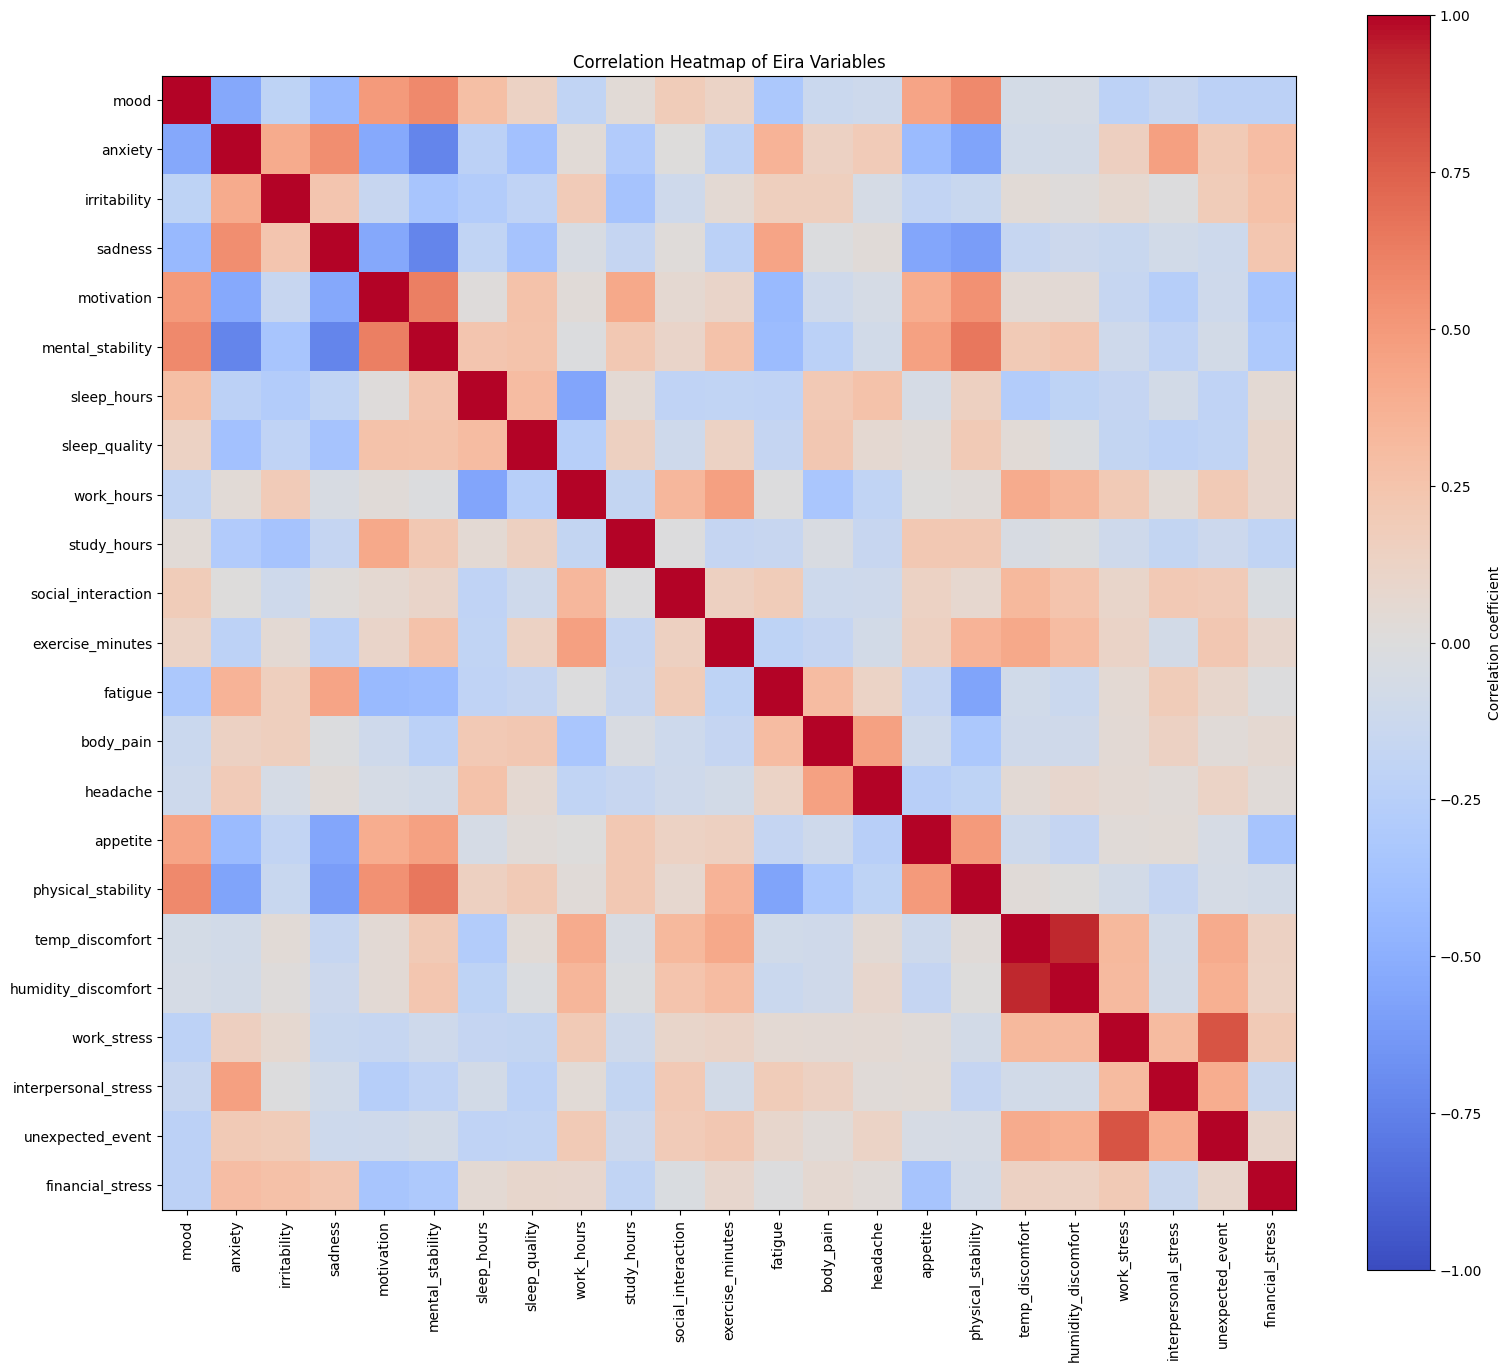

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 14))

image = ax.imshow(
    corr,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)

fig.colorbar(image, ax=ax, label="Correlation coefficient")

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)

ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)

ax.set_title("Correlation Heatmap of Eira Variables")

fig.tight_layout()

fig.savefig(
    "correlation_heatmap.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [13]:
corr.round(2)

,mood,anxiety,irritability,sadness,motivation,mental_stability,sleep_hours,sleep_quality,work_hours,study_hours,...,body_pain,headache,appetite,physical_stability,temp_discomfort,humidity_discomfort,work_stress,interpersonal_stress,unexpected_event,financial_stress
mood,1.00,-0.54,-0.21,-0.43,0.49,0.58,0.29,0.13,-0.19,0.03,...,-0.13,-0.11,0.44,0.57,-0.07,-0.06,-0.21,-0.15,-0.22,-0.23
anxiety,-0.54,1.00,0.40,0.55,-0.54,-0.73,-0.22,-0.37,0.04,-0.29,...,0.14,0.19,-0.42,-0.57,-0.08,-0.07,0.15,0.46,0.20,0.29
irritability,-0.21,0.40,1.00,0.24,-0.15,-0.34,-0.28,-0.20,0.19,-0.35,...,0.16,-0.06,-0.18,-0.15,0.04,0.01,0.07,-0.00,0.18,0.27
sadness,-0.43,0.55,0.24,1.00,-0.54,-0.73,-0.19,-0.35,-0.05,-0.17,...,-0.01,0.03,-0.55,-0.61,-0.16,-0.12,-0.14,-0.08,-0.11,0.23
motivation,0.49,-0.54,-0.15,-0.54,1.00,0.62,0.01,0.26,0.03,0.42,...,-0.11,-0.06,0.39,0.53,0.04,0.05,-0.16,-0.26,-0.11,-0.34
mental_stability,0.58,-0.73,-0.34,-0.73,0.62,1.00,0.24,0.26,-0.01,0.22,...,-0.23,-0.08,0.45,0.65,0.20,0.23,-0.11,-0.20,-0.07,-0.31
sleep_hours,0.29,-0.22,-0.28,-0.19,0.01,0.24,1.00,0.30,-0.56,0.05,...,0.20,0.26,-0.06,0.15,-0.28,-0.21,-0.16,-0.08,-0.20,0.05
sleep_quality,0.13,-0.37,-0.20,-0.35,0.26,0.26,0.30,1.00,-0.26,0.15,...,0.22,0.06,0.03,0.20,0.04,-0.02,-0.17,-0.21,-0.19,0.09
work_hours,-0.19,0.04,0.19,-0.05,0.03,-0.01,-0.56,-0.26,1.00,-0.18,...,-0.33,-0.19,0.01,0.03,0.41,0.34,0.20,0.03,0.20,0.08
study_hours,0.03,-0.29,-0.35,-0.17,0.42,0.22,0.05,0.15,-0.18,1.00,...,-0.04,-0.16,0.22,0.21,-0.04,-0.02,-0.10,-0.18,-0.12,-0.19


In [14]:
# 相関係数をランキング形式にする

corr_pairs = corr.unstack()

# 自分同士（1.00）は除外
corr_pairs = corr_pairs[corr_pairs != 1]

# A-B と B-A の重複を削除
corr_pairs = corr_pairs.drop_duplicates()

# 絶対値が大きい順に並べる
corr_pairs = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)

# 上位20件を表示
corr_pairs.head(20)

temp_discomfort   humidity_discomfort    0.930229
work_stress       unexpected_event       0.794325
anxiety           mental_stability      -0.728977
sadness           mental_stability      -0.727918
mental_stability  physical_stability     0.651722
motivation        mental_stability       0.619110
sadness           physical_stability    -0.605517
mood              mental_stability       0.576657
                  physical_stability     0.571895
fatigue           physical_stability    -0.567474
anxiety           physical_stability    -0.566231
sleep_hours       work_hours            -0.555181
sadness           appetite              -0.549503
anxiety           sadness                0.549379
mood              anxiety               -0.542771
sadness           motivation            -0.539358
anxiety           motivation            -0.536858
motivation        physical_stability     0.532188
appetite          physical_stability     0.499873
mood              motivation             0.493216
dtype: float64